In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e3/train.csv
/kaggle/input/competitions/playground-series-s6e3/test.csv


In [12]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

**READ DATA**

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
test  = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/test.csv")

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("\nChurn Distribution:\n", train["Churn"].value_counts())

Train shape: (594194, 21)
Test shape:  (254655, 20)

Churn Distribution:
 Churn
No     460377
Yes    133817
Name: count, dtype: int64


**Check Missing Value**

In [3]:

print("\n缺失值:\n", train.isnull().sum())
print("\n数据类型:\n", train.dtypes)


缺失值:
 id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

数据类型:
 id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Monthl

**EDA By Plots**

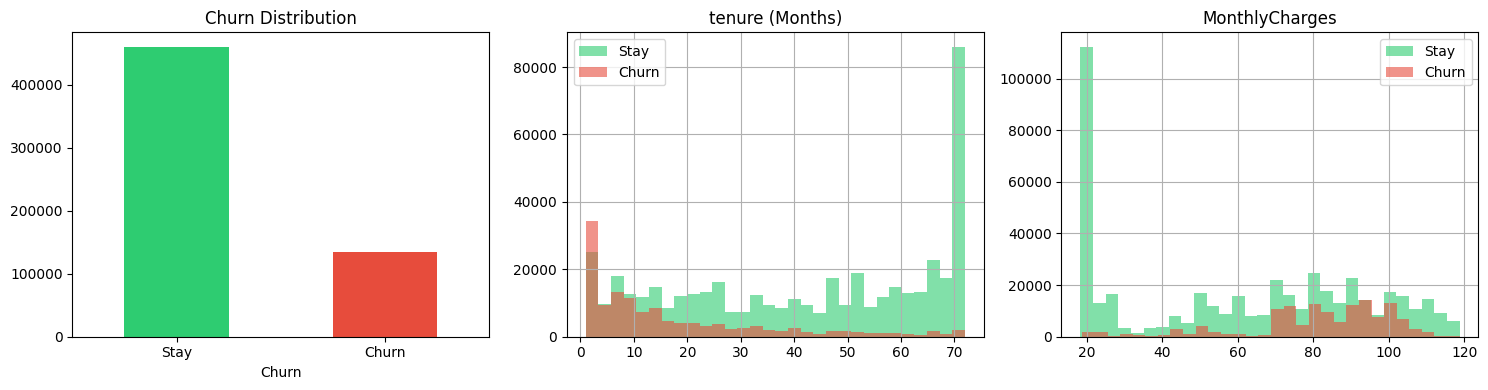

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Churn Distribution
train["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Distribution")
axes[0].set_xticklabels(["Stay", "Churn"], rotation=0)

# tenure
for churn_val, color, label in zip(["No", "Yes"], ["#2ecc71", "#e74c3c"], ["Stay", "Churn"]):
    train[train["Churn"] == churn_val]["tenure"].hist(
        alpha=0.6, ax=axes[1], bins=30, color=color, label=label)
axes[1].set_title("tenure (Months)")
axes[1].legend()

# MonthlyCharges
for churn_val, color, label in zip(["No", "Yes"], ["#2ecc71", "#e74c3c"], ["Stay", "Churn"]):
    train[train["Churn"] == churn_val]["MonthlyCharges"].hist(
        alpha=0.6, ax=axes[2], bins=30, color=color, label=label)
axes[2].set_title("MonthlyCharges")
axes[2].legend()

plt.tight_layout()
plt.show()

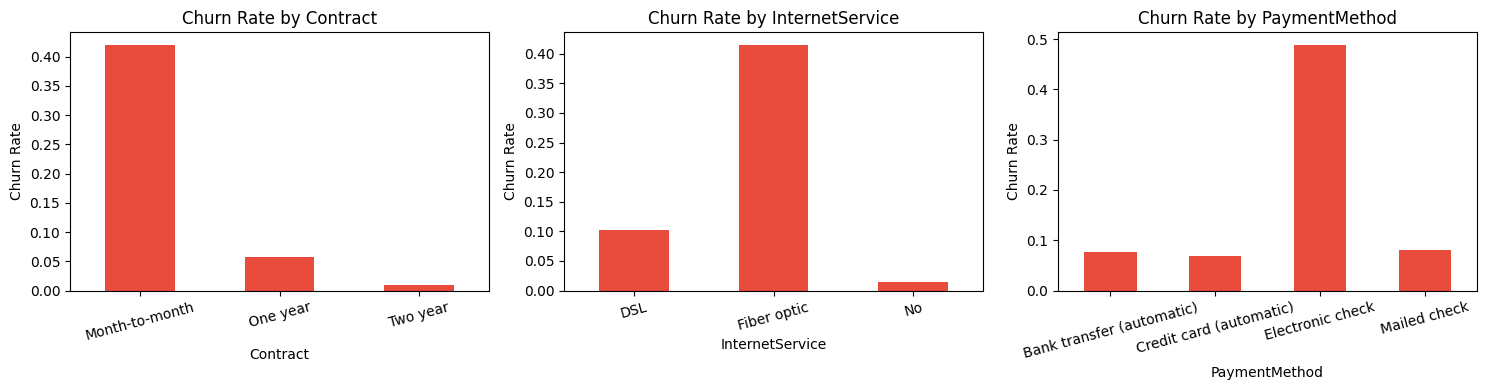

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    churn_rate = train.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rate.plot(kind="bar", ax=ax, color="#e74c3c")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

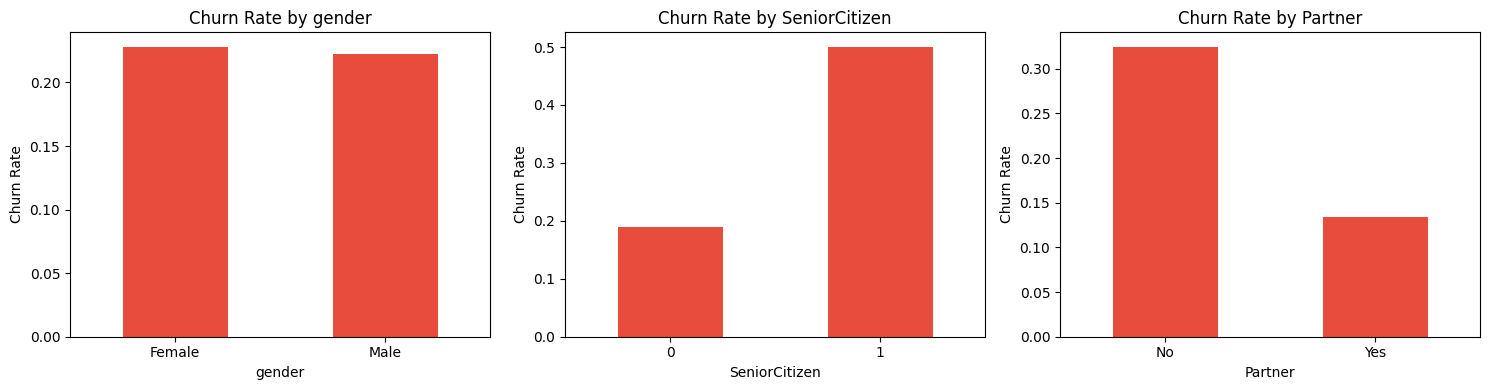

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["gender", "SeniorCitizen", "Partner"]):
    churn_rate = train.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    churn_rate.plot(kind="bar", ax=ax, color="#e74c3c")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

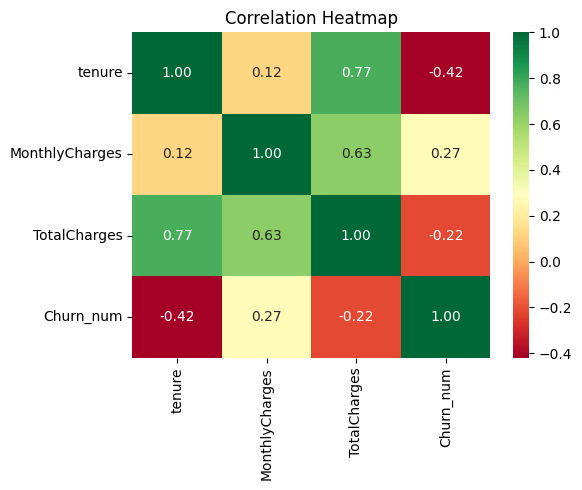

In [10]:
import seaborn as sns

train["Churn_num"] = (train["Churn"] == "Yes").astype(int)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "Churn_num"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(train[num_cols].corr(), annot=True, fmt=".2f", cmap="RdYlGn", ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**LightGBM Baseline**

First step: Preprocessing

In [19]:
target = "Churn"
drop_cols = ["id", target, "Churn_num"]

test["Churn"] = np.nan
combined = pd.concat([train, test], axis=0).reset_index(drop=True)

# LabelEncoder 处理类别特征
cat_cols = combined.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != target]  # Churn 不编码

le = LabelEncoder()
for col in cat_cols:
    combined[col] = le.fit_transform(combined[col].astype(str))

# 拆回 train / test
train_processed = combined[combined[target].notna()].copy()
test_processed  = combined[combined[target].isna()].copy()

feature_cols = [c for c in train_processed.columns if c not in drop_cols]

X      = train_processed[feature_cols]
y      = (train_processed[target] == "Yes").astype(int)  # Yes→1, No→0
X_test = test_processed[feature_cols]


LightGBM + 5 Folders CV

In [20]:
params = {
    "objective":         "binary",
    "metric":            "auc",
    "learning_rate":     0.05,
    "num_leaves":        64,
    "min_child_samples": 20,
    "feature_fraction":  0.8,
    "bagging_fraction":  0.8,
    "bagging_freq":      1,
    "verbosity":         -1,
    "random_state":      42,
}

N_SPLITS   = 5
skf        = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx],  y.iloc[val_idx]

    model = lgb.LGBMClassifier(**params, n_estimators=1000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
    )

    oof_preds[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_preds         += model.predict_proba(X_test)[:, 1] / N_SPLITS

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"Fold {fold+1} AUC: {fold_auc:.5f}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.914225
[200]	valid_0's auc: 0.915332
[300]	valid_0's auc: 0.915542
Early stopping, best iteration is:
[324]	valid_0's auc: 0.915593
Fold 1 AUC: 0.91559
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.91542
[200]	valid_0's auc: 0.916377
[300]	valid_0's auc: 0.916661
[400]	valid_0's auc: 0.916768
[500]	valid_0's auc: 0.916805
Early stopping, best iteration is:
[530]	valid_0's auc: 0.916822
Fold 2 AUC: 0.91682
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.914721
[200]	valid_0's auc: 0.915715
[300]	valid_0's auc: 0.91597
[400]	valid_0's auc: 0.916082
[500]	valid_0's auc: 0.916116
Early stopping, best iteration is:
[510]	valid_0's auc: 0.916117
Fold 3 AUC: 0.91612
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.915829
[200]	valid_0's auc: 0.916789
[300]	valid_0's auc: 0.917091
[400]	valid_0's auc: 0.

  OOF AUC 

In [21]:

overall_auc = roc_auc_score(y, oof_preds)
print(f"\nOverall OOF AUC: {overall_auc:.5f}")

# Submission File 
submission = pd.DataFrame({
    "id":    test_processed["id"].astype(int).values,
    "Churn": test_preds,
})
submission.to_csv("submission.csv", index=False)
print("\nDone! Preview:")
print(submission.head())


Overall OOF AUC: 0.91603

Done! Preview:
       id     Churn
0  594194  0.057397
1  594195  0.000577
2  594196  0.111581
3  594197  0.003345
4  594198  0.487462


**XGBoost**

In [22]:
from xgboost import XGBClassifier

xgb_oof_preds  = np.zeros(len(X))
xgb_test_preds = np.zeros(len(X_test))

xgb_params = {
    "objective":        "binary:logistic",
    "eval_metric":      "auc",
    "learning_rate":    0.05,
    "max_depth":        6,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "random_state":     42,
    "verbosity":        0,
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx],  y.iloc[val_idx]

    model = XGBClassifier(**xgb_params, n_estimators=1000, early_stopping_rounds=50)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=100,
    )

    xgb_oof_preds[val_idx]  = model.predict_proba(X_val)[:, 1]
    xgb_test_preds         += model.predict_proba(X_test)[:, 1] / N_SPLITS

    fold_auc = roc_auc_score(y_val, xgb_oof_preds[val_idx])
    print(f"Fold {fold+1} AUC: {fold_auc:.5f}")

xgb_overall_auc = roc_auc_score(y, xgb_oof_preds)
print(f"\nXGBoost Overall OOF AUC: {xgb_overall_auc:.5f}")

[0]	validation_0-auc:0.90189
[100]	validation_0-auc:0.91331
[200]	validation_0-auc:0.91498
[300]	validation_0-auc:0.91559
[400]	validation_0-auc:0.91586
[500]	validation_0-auc:0.91597
[600]	validation_0-auc:0.91600
[621]	validation_0-auc:0.91599
Fold 1 AUC: 0.91603
[0]	validation_0-auc:0.90204
[100]	validation_0-auc:0.91434
[200]	validation_0-auc:0.91598
[300]	validation_0-auc:0.91663
[400]	validation_0-auc:0.91686
[500]	validation_0-auc:0.91698
[600]	validation_0-auc:0.91702
[684]	validation_0-auc:0.91701
Fold 2 AUC: 0.91702
[0]	validation_0-auc:0.90144
[100]	validation_0-auc:0.91375
[200]	validation_0-auc:0.91538
[300]	validation_0-auc:0.91605
[400]	validation_0-auc:0.91632
[500]	validation_0-auc:0.91646
[600]	validation_0-auc:0.91650
[662]	validation_0-auc:0.91650
Fold 3 AUC: 0.91651
[0]	validation_0-auc:0.90283
[100]	validation_0-auc:0.91494
[200]	validation_0-auc:0.91653
[300]	validation_0-auc:0.91719
[400]	validation_0-auc:0.91746
[500]	validation_0-auc:0.91758
[600]	validation_0

**CatBoost**

In [23]:
from catboost import CatBoostClassifier

# CatBoost 直接用原始数据，不需要 LabelEncoder 处理过的
cat_feature_cols = [c for c in train.columns if c not in ["id", "Churn", "Churn_num"]]
X_cat       = train[cat_feature_cols]
X_cat_test  = test[cat_feature_cols]

# 找出类别列
catboost_cat_cols = X_cat.select_dtypes(include="object").columns.tolist()

cb_oof_preds  = np.zeros(len(X_cat))
cb_test_preds = np.zeros(len(X_cat_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cat, y)):
    X_tr, X_val = X_cat.iloc[train_idx], X_cat.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx],      y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        eval_metric="AUC",
        random_seed=42,
        verbose=100,
        early_stopping_rounds=50,
        cat_features=catboost_cat_cols,
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    cb_oof_preds[val_idx]  = model.predict_proba(X_val)[:, 1]
    cb_test_preds         += model.predict_proba(X_cat_test)[:, 1] / N_SPLITS

    fold_auc = roc_auc_score(y_val, cb_oof_preds[val_idx])
    print(f"Fold {fold+1} AUC: {fold_auc:.5f}")

cb_overall_auc = roc_auc_score(y, cb_oof_preds)
print(f"\nCatBoost Overall OOF AUC: {cb_overall_auc:.5f}")

0:	test: 0.8723458	best: 0.8723458 (0)	total: 715ms	remaining: 11m 54s
100:	test: 0.9120521	best: 0.9120521 (100)	total: 49.6s	remaining: 7m 21s
200:	test: 0.9133561	best: 0.9133561 (200)	total: 1m 37s	remaining: 6m 26s
300:	test: 0.9141513	best: 0.9141513 (300)	total: 2m 26s	remaining: 5m 40s
400:	test: 0.9147107	best: 0.9147107 (400)	total: 3m 18s	remaining: 4m 56s
500:	test: 0.9150220	best: 0.9150220 (500)	total: 4m 9s	remaining: 4m 8s
600:	test: 0.9152666	best: 0.9152666 (600)	total: 5m 1s	remaining: 3m 20s
700:	test: 0.9154708	best: 0.9154708 (699)	total: 5m 53s	remaining: 2m 30s
800:	test: 0.9156150	best: 0.9156150 (800)	total: 6m 45s	remaining: 1m 40s
900:	test: 0.9157210	best: 0.9157210 (900)	total: 7m 38s	remaining: 50.3s
999:	test: 0.9158035	best: 0.9158035 (999)	total: 8m 29s	remaining: 0us

bestTest = 0.9158035289
bestIteration = 999

Fold 1 AUC: 0.91580
0:	test: 0.8743336	best: 0.8743336 (0)	total: 643ms	remaining: 10m 42s
100:	test: 0.9133121	best: 0.9133121 (100)	total: 

Three model fusion

In [24]:
# 三模型等权平均
final_preds = (test_preds + xgb_test_preds + cb_test_preds) / 3

# 融合后的 OOF AUC
fusion_oof = (oof_preds + xgb_oof_preds + cb_oof_preds) / 3
fusion_auc = roc_auc_score(y, fusion_oof)
print(f"LightGBM OOF AUC: {roc_auc_score(y, oof_preds):.5f}")
print(f"XGBoost  OOF AUC: {roc_auc_score(y, xgb_oof_preds):.5f}")
print(f"CatBoost OOF AUC: {roc_auc_score(y, cb_oof_preds):.5f}")
print(f"融合后   OOF AUC: {fusion_auc:.5f}")

# 生成提交文件
submission = pd.DataFrame({
    "id":    test_processed["id"].astype(int).values,
    "Churn": final_preds,
})
submission.to_csv("submission.csv", index=False)
print("\nDone! Preview:")
print(submission.head())

LightGBM OOF AUC: 0.91603
XGBoost  OOF AUC: 0.91641
CatBoost OOF AUC: 0.91613
融合后   OOF AUC: 0.91652

Done! Preview:
       id     Churn
0  594194  0.065282
1  594195  0.000828
2  594196  0.108663
3  594197  0.003301
4  594198  0.485879
